In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
from corner import corner
from getdist import plots
import scienceplots
from os.path import exists
import seaborn as sns

import sys
sys.path.append("../")
from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

COLS = ['#006FED', '#E03424', 'gray', '#009966',
        '#000866', '#336600', '#006633', 'm', 'r']

## Quick checks

In [66]:
def get_fname(simname, catalogue, sample_mag_dipole):
    """We read off the evidence in support of the dipole."""
    zcmb_max = 0.0750001 if "no_field" in simname else 0.0500021

    sample_alpha = False if "no_field" in simname else True
    sample_beta = False if "no_field" in simname else None

    return paths.flow_validation(
        fdir, simname, catalogue=catalogue, inference_method="mike",
        sample_alpha=sample_alpha, sample_beta=sample_beta,
        sample_mag_dipole=sample_mag_dipole, dust_model=None,
        mag_dipole_prior_kind="fixed",
        zcmb_max=zcmb_max)



# catalogue = ["CF4_TFR_i", "CF4_TFR_notSDSS_w1"]
catalogue = "CF4_TFR_w2"
fname = get_fname("Carrick2015", catalogue, True)
# print("logZ = ", -get_gof("neg_lnZ_harmonic", fname) / np.log(10))
samples = get_some_samples(fname, ["Vext", "mag_dipole", "aTFR"])

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w2_mike_zcmb_max_0.0500021_sample_alpha_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 20/02/2025 03:27:53


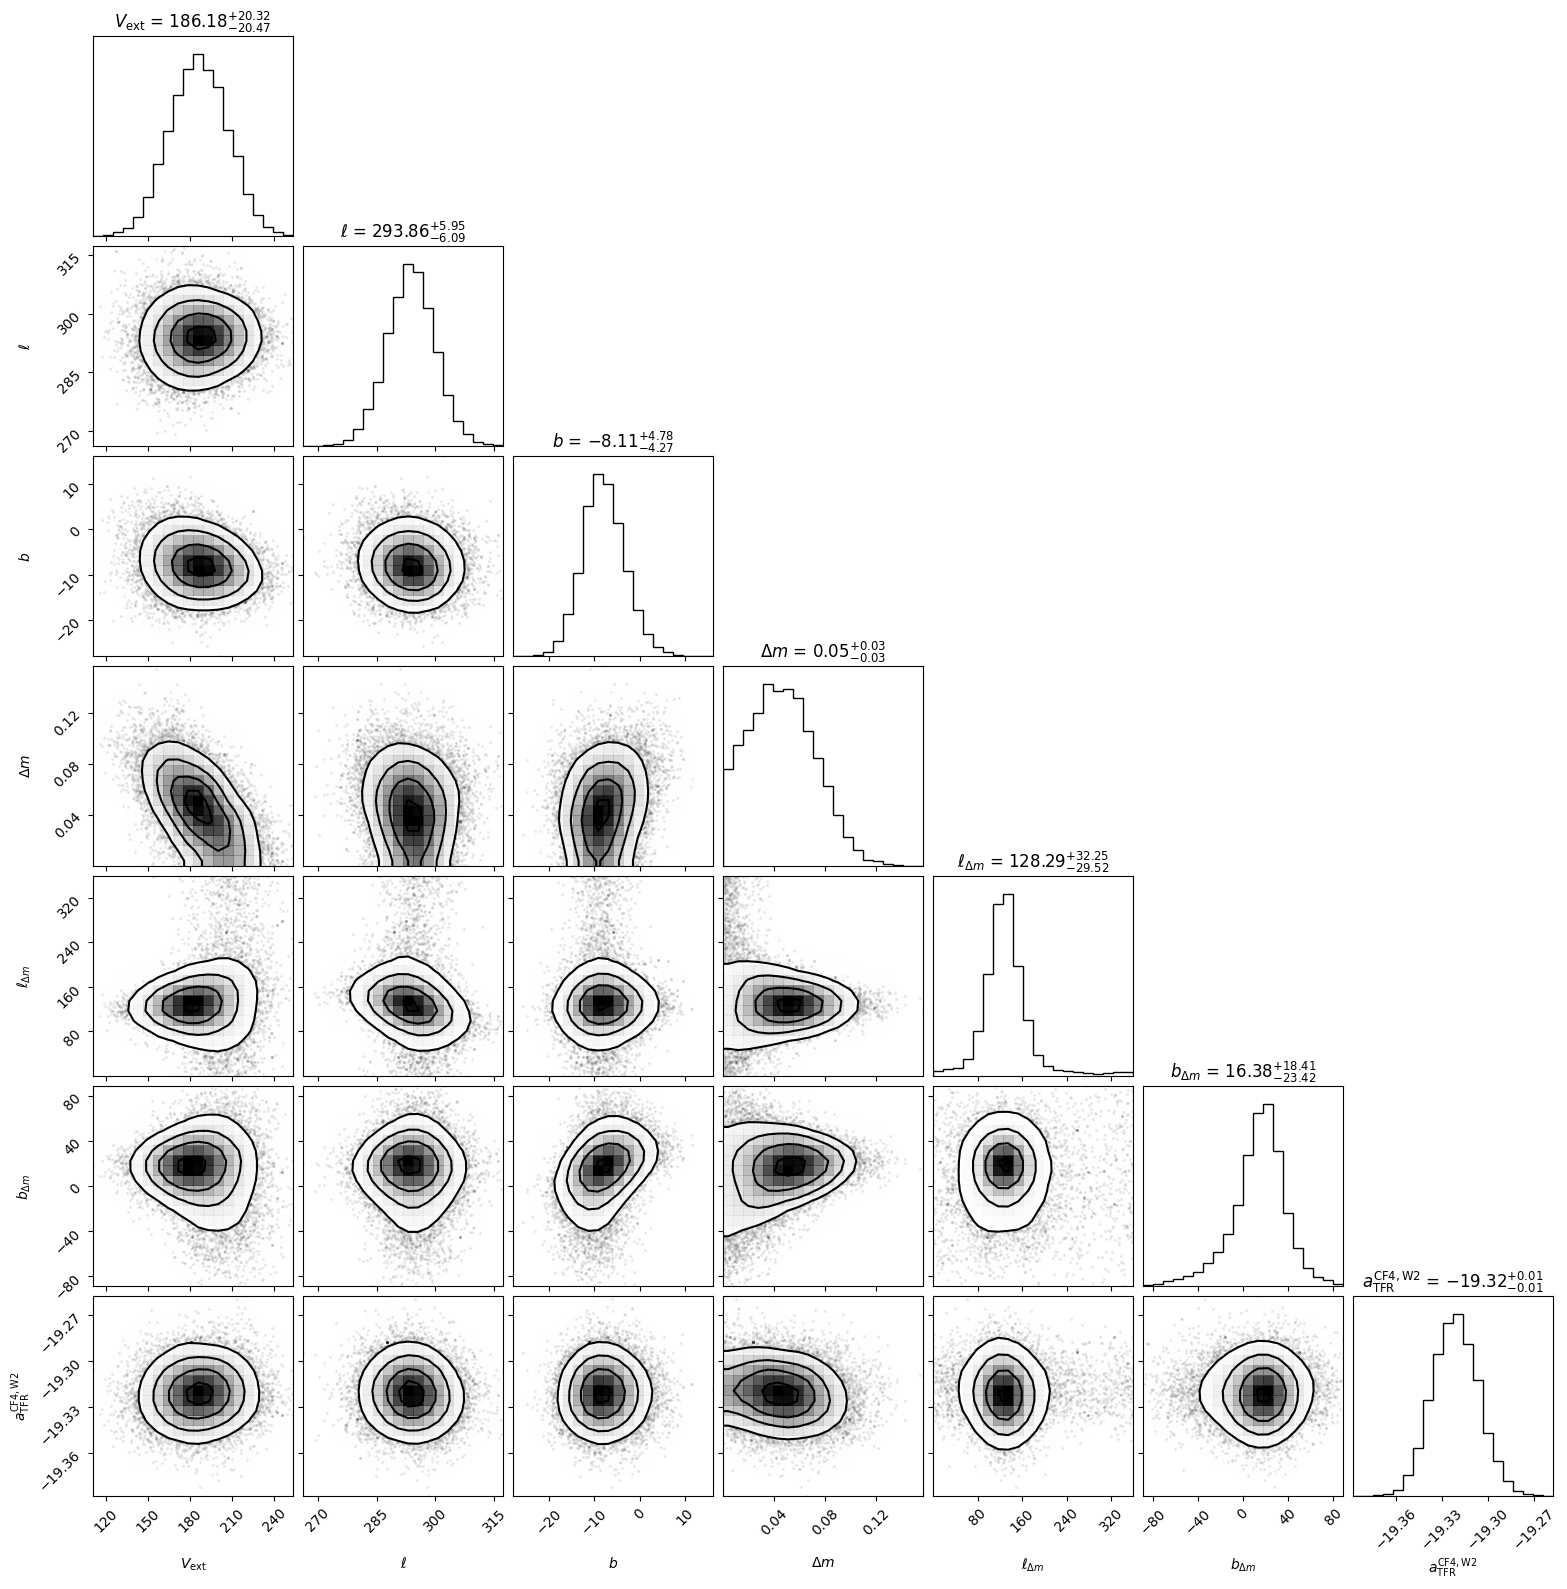

In [67]:
corner_samples, labels, keys = samples_for_corner(samples)

fig = corner(corner_samples, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1)
# fig.savefig("../../../plots/corner.png", dpi=250)
fig.show()

## Data results

### Evidence comparison

In [31]:
def get_fname(simname, catalogue, sample_mag_dipole):
    """We read off the evidence in support of the dipole."""
    zcmb_max = 0.0750001 if "no_field" in simname else 0.0500021

    sample_alpha = False if "no_field" in simname else True
    sample_beta = False if "no_field" in simname else None

    return paths.flow_validation(
        fdir, simname, catalogue=catalogue, inference_method="mike",
        sample_alpha=sample_alpha, sample_beta=sample_beta,
        sample_mag_dipole=sample_mag_dipole, dust_model=None,
        mag_dipole_prior_kind="fixed",
        zcmb_max=zcmb_max)


def read_dlogZ(simname, catalogue):
    return get_gof("logZ_harmonic", get_fname(simname, catalogue, True), ) - get_gof("logZ_harmonic", get_fname(simname, catalogue, False), )


In [36]:
catalogues = ["SFI_gals", "2MTF", "CF4_TFR_w1", "CF4_TFR_w2",
              # ["CF4_TFR_i", "CF4_TFR_notSDSS_w1"],
              ]

logB_no_field = np.asarray([read_dlogZ("no_field_400", catalogue) for catalogue in catalogues])
logB_carrick = np.asarray([read_dlogZ("Carrick2015", catalogue) for catalogue in catalogues])

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_SFI_gals_mike_zcmb_max_0.0750001_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 20/02/2025 02:59:58
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_SFI_gals_mike_zcmb_max_0.0750001_mag_dipole_prior_kind_fixed.hdf5
Last modified: 20/02/2025 02:52:29
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_2MTF_mike_zcmb_max_0.0750001_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 20/02/2025 03:00:37
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_2MTF_mike_zcmb_max_0.0750001_mag_dipole_prior_kind_fixed.hdf5
Last modified: 20/02/2025 02:49:59
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_CF4_TFR_w1_mike_zcmb_max_0.0750001_sample_mag_di

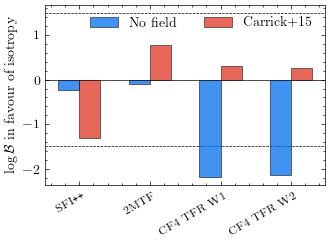

In [40]:
import matplotlib.transforms as mtransforms

x = np.arange(len(catalogues))
width = 0.3

with plt.style.context("science"):
    fig, ax = plt.subplots()

    ax.bar(x - width/2, -logB_no_field, width=width,
           label=simname_to_pretty("no_field_400"), color=COLS[0], alpha=0.75,
           edgecolor="black", linewidth=0.5)
    ax.bar(x + width/2, -logB_carrick, width=width,
            label=simname_to_pretty("Carrick2015"), color=COLS[1], alpha=0.75,
            edgecolor="black", linewidth=0.5)

    ax.set_ylabel(r"$\log \mathcal{B}$ in favour of isotropy")
    ax.set_xticks(ticks=x, labels=[catalogue_to_pretty(c) for c in catalogues],
               rotation=45, fontsize="small")

    ax.set_xticks(x, [catalogue_to_pretty(c) for c in catalogues], rotation=30,
                  ha="right")
    offset = mtransforms.ScaledTranslation(5 / 72, 0, fig.dpi_scale_trans)
    for label in ax.get_xticklabels():
        label.set_transform(label.get_transform() + offset)


    ax.axhline(1.5, color="black", linestyle="--", linewidth=0.5, zorder=0)
    ax.axhline(-1.5, color="black", linestyle="--", linewidth=0.5, zorder=0)
    ax.axhline(0, color="black", linewidth=0.5, zorder=0)

    plt.legend(ncols=2)
    plt.tight_layout()
    plt.savefig("../../../plots/logB_data.pdf", dpi=450)
    plt.show()



### Posterior per simulation

In [43]:
def get_samples_per_catalogue(catalogue, simnames, params, sample_mag_dipole):
    ranges = {
        "Vmag":[0, None],
        "sigma_v": [0, None],
        "mag_dipole_mag": [0, None],
        }


    X = []
    for simname in simnames:
        fname = get_fname(simname, catalogue, sample_mag_dipole)
        samples = get_some_samples(fname, params, )
        samples = samples_to_getdist(samples, simname_to_pretty(simname), ranges=ranges)

        X.append(samples)
    return X


catalogue = "CF4_TFR_w1"
X = get_samples_per_catalogue(
    catalogue, ["Carrick2015", "no_field_400"],
    ["Vext", "sigma_v", "mag_dipole"],
    sample_mag_dipole=True)

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_CF4_TFR_w1_mike_zcmb_max_0.0500021_sample_alpha_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 20/02/2025 03:29:16
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_CF4_TFR_w1_mike_zcmb_max_0.0750001_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 20/02/2025 03:14:51
Removed no burn in


/tmp/ipykernel_2073069/1722963880.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


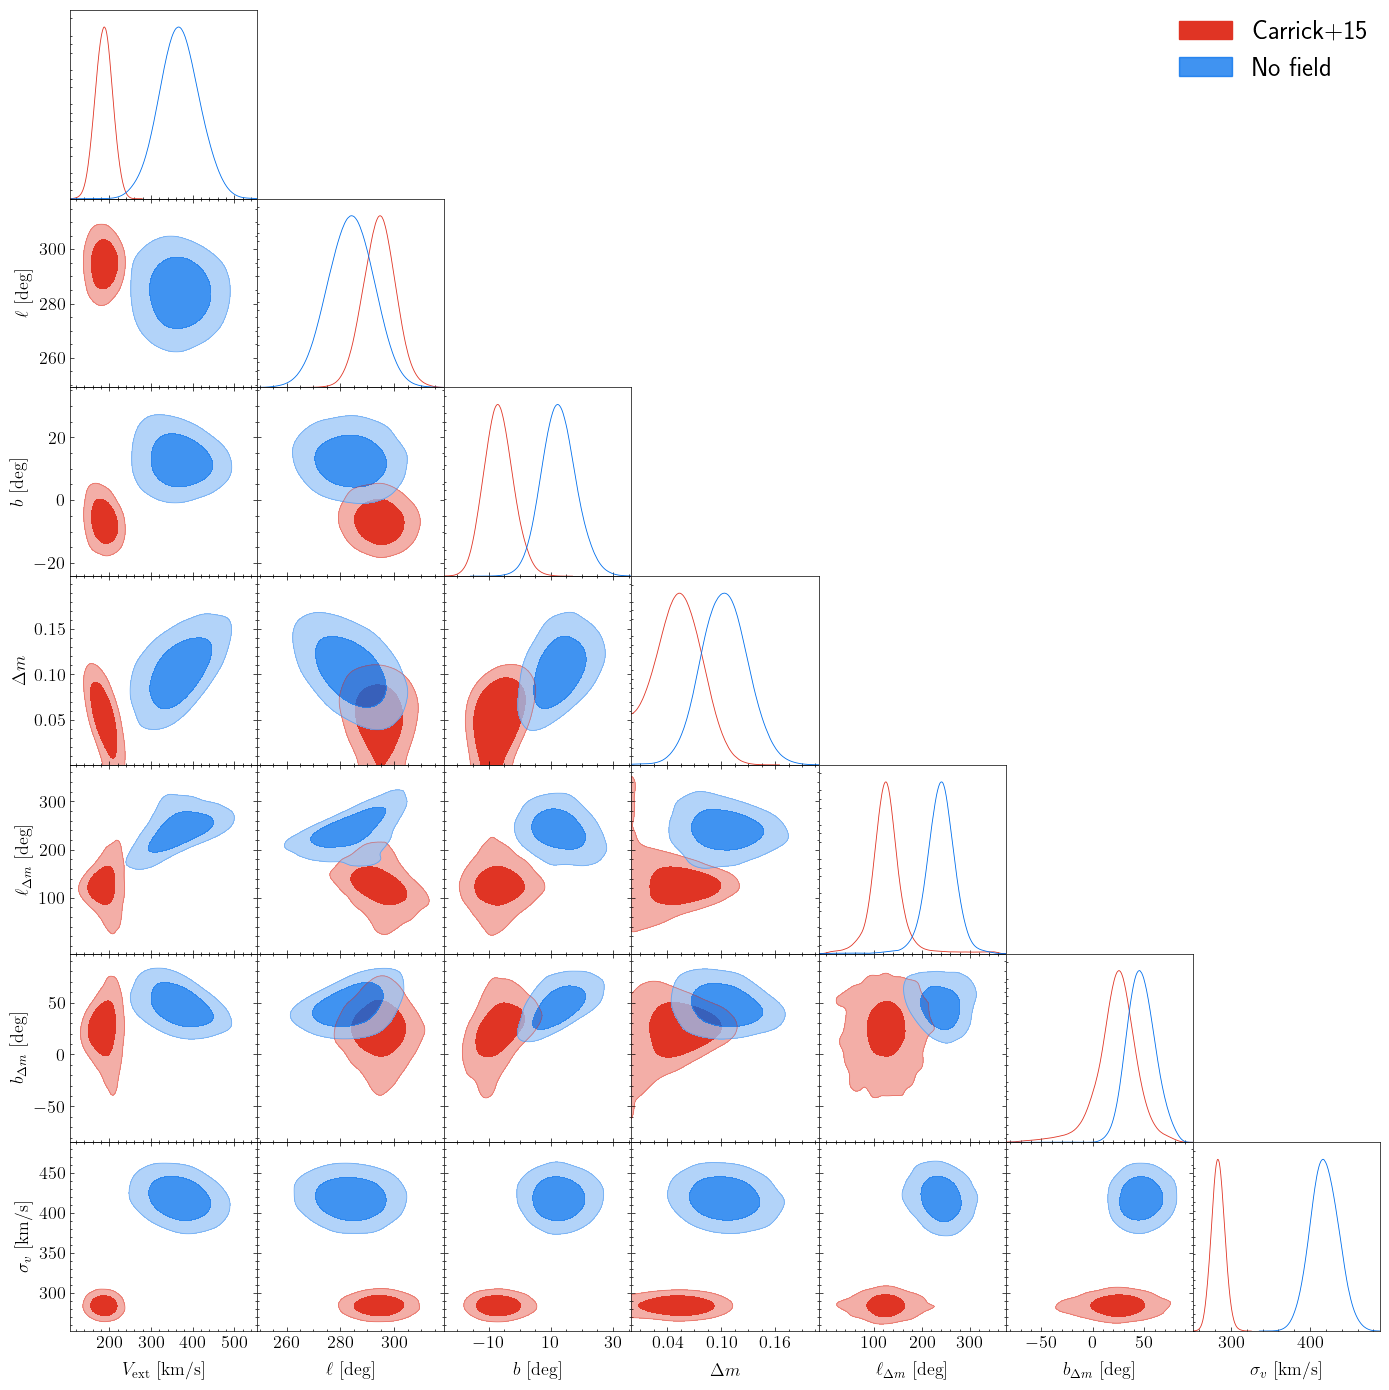

In [44]:
with plt.style.context('science'):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.legend_fontsize = 22
    g.settings.axes_labelsize = 16
    g.settings.axes_fontsize = 16

    g.triangle_plot(X, filled=True, legend_loc='upper right')

    plt.gcf().tight_layout()
    plt.gcf().savefig(f"../../../plots/aTFR_per_catalogue_{catalogue}.pdf", dpi=450, bbox_inches='tight')
    plt.gcf().show()


### Posterior per catalogue

In [58]:
def get_samples_per_simname(catalogues, simname, params, sample_mag_dipole):
    ranges = {
        "Vmag":[0, None],
        "sigma_v": [0, None],
        "mag_dipole_mag": [0, None],
        }

    X = []
    for catalogue in catalogues:
        fname = get_fname(simname, catalogue, sample_mag_dipole)
        samples = get_some_samples(fname, params, )
        samples = samples_to_getdist(samples, catalogue_to_pretty(catalogue), ranges=ranges)

        X.append(samples)
    return X



simname = "no_field_400"
X = get_samples_per_simname(
    ["SFI_gals", "2MTF", "CF4_TFR_w1", "CF4_TFR_w2"], simname, ["mag_dipole"], sample_mag_dipole=True)

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_SFI_gals_mike_zcmb_max_0.0750001_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 20/02/2025 02:59:58
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_2MTF_mike_zcmb_max_0.0750001_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 20/02/2025 03:00:37
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_CF4_TFR_w1_mike_zcmb_max_0.0750001_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 20/02/2025 03:14:51
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_400_CF4_TFR_w2_mike_zcmb_max_0.0750001_sample_mag_dipole_mag_dipole_prior_kind_fixed.hdf5
Last modified: 20/02/2025 03:10:54
Removed no burn in


/tmp/ipykernel_2073069/3280179581.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


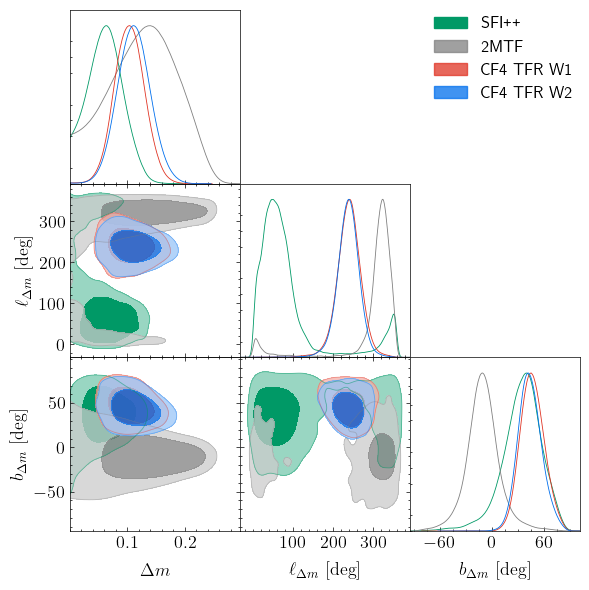

In [59]:
with plt.style.context('science'):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.legend_fontsize = 15
    g.settings.axes_labelsize = 16
    g.settings.axes_fontsize = 16

    g.triangle_plot(X, filled=True, legend_loc='upper right')

    plt.gcf().tight_layout()
    plt.gcf().savefig(f"../../../plots/aTFR_per_simulation_{simname}.pdf", dpi=300, bbox_inches='tight')
    plt.gcf().show()